## Droplet dynamics (Laminar to complex flow transition) - Taylor Green vortex decay test
### Reference: Insights into 2D Navier-Stokes Numerical Simulations, Energy-Conserving Solver Approaches

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.linalg as la
import matplotlib.animation as animation
from skimage import measure

from pathlib import Path
import json
from datetime import datetime

In [2]:
## Grid has N^2 points (2D)
## Periodic domain (D = l^d), l = length of the side of d-dimensional hypercubic domain


# Domain 
L_x = 2*np.pi
L_y = 2*np.pi
N_x = 256
N_y = 256

# 2D periodic grid
del_x = L_x/N_x
del_y = L_y/N_y
x_j = np.arange(N_x) * del_x
y_j = np.arange(N_y) * del_y
X, Y = np.meshgrid(x_j, y_j, indexing='xy')

# Wrapped wavenumber arrays
n_x = np.arange(N_x)
n_y = np.arange(N_y)
k_x = (2*np.pi/L_x) * np.where(n_x <= N_x/2, n_x, n_x - N_x)
k_y = (2*np.pi/L_y) * np.where(n_y <= N_y/2, n_y, n_y - N_y)
Kx, Ky = np.meshgrid(k_x, k_y, indexing='xy')

K2 = Kx**2 + Ky**2

dx = 2*np.pi/N_x
# diffuse interface
epsilon = 3*dx
# 0.03
# 4*dx

# Kinematic velocity/viscosity - responsible for turbulent flow
nu = 0.05
# 4.67e-3

# Friction coefficient
alpha = 0.0
# 1e-3

# Mobility in Cahn-Hilliard equation
M = 4e-4
# 6e-4
# epsilon**2

# Low sigma could break the interface
sigma = 1.0

lamda_01 = -nu*K2 - alpha
lamda_02 = (-3/2)*M*sigma*epsilon*K2**2 + (3/4)*(sigma/epsilon)*M*K2 # M*sigma*epsilon*dt*K**4/2 or 3 must be less than 1, M and dt have inverse relation

# Reference for the following: Interface-induced turbulence in viscous binary fluid mixtures Supplemental Material
# Amplitude
f_0 = 3.0
# 5.0

# Wavenumber, Decreasing this causes advection, should be an integer
k_f = 4

# Forcing
# f_w = f_0 * k_f * (np.cos(k_f * X) + np.cos(k_f * Y))
# f_w_hat = np.fft.fft2(f_w)

# Time stepping
# T = 8.0
# N_t = 25000
# delta_t = T/N_t
# save_every = 100

T = 10.0
N_t = 25000
delta_t = T/N_t
save_every = 100

# Single droplet parameters

# xc = L_x / 2
# yc = L_y / 2

# xc = 0.47 * L_x
# yc = 0.41 * L_y

# d0 = 0.24 * L_x      

In [3]:
experiment_name = "Experiment_DD_Taylor_Green"

def create_experiment_folder(experiment_name, base_dir="Results"):
    """
    Creates:
        Results/<experiment_name>/
    """
    experiment_dir = Path(base_dir) / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)
    return {
        "experiment_dir": experiment_dir
    }


dirs = create_experiment_folder(experiment_name)

experiment_dir = dirs["experiment_dir"]
plots_dir = experiment_dir
animations_dir = experiment_dir

In [4]:
parameters = {

    # Experiment metadata
    "experiment_name": experiment_name,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "description": "laminar to complex",

    # Domain
    "domain": {
        "dimension": 2,
        "geometry": "periodic square domain",
        "L_x": float(L_x),
        "L_y": float(L_y),
        "N_x": int(N_x),
        "N_y": int(N_y),
        "del_x": float(del_x),
        "del_y": float(del_y),
        "dx": float(dx),
        "grid_points": int(N_x * N_y),
    },

    # Physical parameters
    "physical_parameters": {
        "epsilon": float(epsilon),
        "epsilon_definition": "epsilon = 3 * dx",
        "nu": float(nu),
        "alpha": float(alpha),
        "M": float(M),
        "sigma": float(sigma),
    },


    # Forcing
    "forcing": {
        # "type": "Kolmogorov-type forcing",
        # "reference": "Interface-induced turbulence in viscous binary fluid mixtures, Supplemental Material",
        "f_0": float(f_0),
        "k_f": k_f,
        "definition": "f_w = f_0 * k_f * (np.cos(k_f * X) + np.cos(k_f * Y))",
    },


    # Time stepping
    "time_stepping": {
        "T": float(T),
        "N_t": int(N_t),
        "delta_t": float(delta_t),
        "save_every": int(save_every),
        "number_of_saved_snapshots": int(N_t // save_every + 1),
    },
}

def save_parameters(parameters, experiment_dir):
    json_path = experiment_dir / "parameters.json"

    # Save JSON
    with open(json_path, "w") as f:
        json.dump(parameters, f, indent=4)

    print(f"Saved parameters to:\n{json_path}")

save_parameters(parameters, experiment_dir)

Saved parameters to:
Results/Experiment_DD_Taylor_Green/parameters.json


In [5]:
# Initialise phi
phi_xy = np.ones_like(X)
phi_xy_hat = np.fft.fft2(phi_xy)

# Initial vorticity
A = 10
a = 2
b = 2
omega_xy_0 = A * np.sin(a * X) * np.sin(b * Y)
omega_hat = np.fft.fft2(omega_xy_0)

In [6]:
# Integer Fourier mode indices for dealiasing
mx = np.fft.fftfreq(N_x) * N_x
my = np.fft.fftfreq(N_y) * N_y
MX, MY = np.meshgrid(mx, my, indexing='xy')

# 1/2-dealiasing mask for cubic nonlinearities
dealias_mask = ((np.abs(MX) < N_x//4) & (np.abs(MY) < N_y//4)).astype(float)

def dealias(hat_field):
    return hat_field * dealias_mask

In [7]:
# Assemble \mu using pseudo-spectral implementation

print("initial phi stats:", phi_xy.min(), phi_xy.max(), np.mean(phi_xy))
print("initial phi hat finite?", np.isfinite(phi_xy_hat).all())

def mu_spec(phi_hat, phi_xy):
    phi3_hat = dealias(np.fft.fft2(phi_xy**3))
    return (3/2)*sigma*epsilon*K2*phi_hat + (3/4)*(sigma/epsilon)*(phi3_hat - phi_hat)

initial phi stats: 1.0 1.0 1.0
initial phi hat finite? True


In [8]:
# omega = vorticity field

def recover_velocity(omega_hat):
    psi_hat = np.zeros_like(omega_hat, dtype=complex)
    mask = (K2 != 0)
    psi_hat[mask] = omega_hat[mask] / K2[mask]

    u_x_hat = 1j * Ky * psi_hat
    u_y_hat = -1j * Kx * psi_hat

    u_x = np.fft.ifft2(u_x_hat).real
    u_y = np.fft.ifft2(u_y_hat).real

    return u_x,u_y

In [9]:
# Handling Non linear terms in CHNS equation

def advection_phi(phi_xy_hat, u_x, u_y):
    phi_x = np.fft.ifft2(1j * Kx * phi_xy_hat).real
    phi_y = np.fft.ifft2(1j * Ky * phi_xy_hat).real
    adv_xy = phi_x * u_x + phi_y * u_y
    return dealias(np.fft.fft2(adv_xy))

def advection_omega(omega_hat, u_x, u_y):
    omega_x = np.fft.ifft2(1j * Kx * omega_hat).real
    omega_y = np.fft.ifft2(1j * Ky * omega_hat).real
    adv_xy = omega_x * u_x + omega_y * u_y
    return dealias(np.fft.fft2(adv_xy))

# 2D vorticity equation
def coupling_term(phi_xy, mu_spec):
    mu_x = np.fft.ifft2(1j * Kx * mu_spec).real
    mu_y = np.fft.ifft2(1j * Ky * mu_spec).real

    term1_hat = dealias(np.fft.fft2(phi_xy * mu_y))
    term2_hat = dealias(np.fft.fft2(phi_xy * mu_x))

    return -(1j * Kx * term1_hat - 1j * Ky * term2_hat) # minus sign due to how coupling is defined in RP2

In [10]:
# Helper functions for validation


def compute_divergence(u_x, u_y, Kx, Ky):
    """
    Computes divergence of velocity field:
        div u = du_x/dx + du_y/dy
    using spectral derivatives.
    """
    u_x_hat = np.fft.fft2(u_x)
    u_y_hat = np.fft.fft2(u_y)

    div_hat = 1j * Kx * u_x_hat + 1j * Ky * u_y_hat
    div_xy = np.fft.ifft2(div_hat).real

    return div_xy, div_hat


def compute_kinetic_energy(u_x, u_y):
    """
    Kinetic energy per unit area:
        E = 1/2 <u_x^2 + u_y^2>
    """
    return 0.5 * np.mean(u_x**2 + u_y**2)


def compute_enstrophy(omega_xy):
    """
    Enstrophy per unit area:
        Z = 1/2 <omega^2>
    """
    return 0.5 * np.mean(omega_xy**2)


def check_finite_fields(**fields):
    """
    Checks whether all provided arrays contain only finite values.
    """
    results = {}

    for name, arr in fields.items():
        results[name] = np.isfinite(arr).all()

    return results


def analytical_laminar_vorticity(X, Y, f_0, k_f, nu, alpha=0.0):
    """
    Analytical steady vorticity for the forced linear problem:

        0 = nu Delta omega - alpha omega + f_omega

    with

        f_omega = f_0 k_f [cos(k_f x) + cos(k_f y)]

    Then:

        omega_lam = f_0 k_f / (nu k_f^2 + alpha)
                    [cos(k_f x) + cos(k_f y)]
    """
    denominator = nu * k_f**2 + alpha

    return (f_0 * k_f / denominator) * (
        np.cos(k_f * X) + np.cos(k_f * Y)
    )


def compute_error(numerical, analytical):
    """
    Computes common error metrics.
    """
    err = numerical - analytical

    L2_err = np.sqrt(np.mean(err**2))
    Linf_err = np.max(np.abs(err))
    relative_L2_err = L2_err / np.sqrt(np.mean(analytical**2))

    return err, L2_err, Linf_err, relative_L2_err


def taylor_green_exact_vorticity(X, Y, A, a, b, nu, alpha, t):
    """
    Analytical Taylor-Green vorticity solution:

        omega(t,x,y) = A exp(-(nu(a^2+b^2)+alpha)t) sin(ax) sin(by)
    """
    decay_rate = nu * (a**2 + b**2) + alpha
    return A * np.exp(-decay_rate * t) * np.sin(a * X) * np.sin(b * Y)


def taylor_green_exact_enstrophy(E0, decay_rate, t):
    """
    Since omega decays like exp(-decay_rate*t),
    enstrophy decays like exp(-2*decay_rate*t).
    """
    return E0 * np.exp(-2.0 * decay_rate * t)

In [11]:
# Time stepping 

G = lambda omega_hat,phi_xy,mu_s,u_x,u_y: -(advection_omega(omega_hat,u_x,u_y)) + coupling_term(phi_xy,mu_s)
# + f_w_hat 
H = lambda phi_xy_hat,phi_xy,u_x,u_y: -(advection_phi(phi_xy_hat,u_x,u_y)) - (3/4)*(sigma/epsilon)*M*K2*dealias(np.fft.fft2(phi_xy**3))


In [12]:
# Start from Taylor-Green initial vorticity
q_01_n = omega_hat.copy()

# Analytical decay rate
decay_rate = nu * (a**2 + b**2) + alpha
print("Taylor-Green decay rate =", decay_rate)

Taylor-Green decay rate = 0.4


In [13]:

# ============================================================
# Histories
# ============================================================

omega_history = []
time_history = []
kinetic_energy_history = []
enstrophy_history = []
exact_enstrophy_history = []
relative_enstrophy_error_history = []
L2_error_history = []
Linf_error_history = []
relative_L2_error_history = []
max_divergence_history = []
finite_check_history = []

# Initial enstrophy
E0_enstrophy = compute_enstrophy(omega_xy_0)

# Linear ETD exponential
E_01 = np.exp(lamda_01 * delta_t)

# ============================================================
# Time stepping: Taylor-Green linear decay
# ============================================================

for n in range(N_t + 1):

    t = n * delta_t

    # Current physical vorticity
    omega_xy_n = np.fft.ifft2(q_01_n).real

    # Recover velocity
    u_x_n, u_y_n = recover_velocity(q_01_n)

    # Save diagnostics
    if n % save_every == 0:

        # Analytical solution at this time
        omega_exact_n = taylor_green_exact_vorticity(
            X=X,
            Y=Y,
            A=A,
            a=a,
            b=b,
            nu=nu,
            alpha=alpha,
            t=t
        )

        # Error
        error_xy = omega_xy_n - omega_exact_n
        L2_error = np.sqrt(np.mean(error_xy**2))
        Linf_error = np.max(np.abs(error_xy))
        relative_L2_error = L2_error / np.sqrt(np.mean(omega_exact_n**2))

        # Incompressibility
        div_xy, div_hat = compute_divergence(u_x_n, u_y_n, Kx, Ky)
        max_divergence = np.max(np.abs(div_xy))

        # Finite checks
        finite_checks = check_finite_fields(
            omega_hat=q_01_n,
            omega_xy=omega_xy_n,
            u_x=u_x_n,
            u_y=u_y_n,
            div_xy=div_xy
        )

        # Energies
        kinetic_energy = compute_kinetic_energy(u_x_n, u_y_n)
        enstrophy = compute_enstrophy(omega_xy_n)

        exact_enstrophy = taylor_green_exact_enstrophy(
            E0=E0_enstrophy,
            decay_rate=decay_rate,
            t=t
        )

        relative_enstrophy_error = abs(enstrophy - exact_enstrophy) / exact_enstrophy

        # Store histories
        omega_history.append(omega_xy_n.copy())
        time_history.append(t)
        kinetic_energy_history.append(kinetic_energy)
        enstrophy_history.append(enstrophy)
        exact_enstrophy_history.append(exact_enstrophy)
        relative_enstrophy_error_history.append(relative_enstrophy_error)
        L2_error_history.append(L2_error)
        Linf_error_history.append(Linf_error)
        relative_L2_error_history.append(relative_L2_error)
        max_divergence_history.append(max_divergence)
        finite_check_history.append(finite_checks)

        print(
            f"step {n}/{N_t}, "
            f"t={t:.4f}, "
            f"L2={L2_error:.4e}, "
            f"rel_L2={relative_L2_error:.4e}, "
            f"E={enstrophy:.4e}, "
            f"E_exact={exact_enstrophy:.4e}, "
            f"rel_E_err={relative_enstrophy_error:.4e}, "
            f"max|div u|={max_divergence:.4e}"
        )

        if not all(finite_checks.values()):
            print("Non-finite field detected.")
            print(finite_checks)
            break

    # Do not step beyond final time
    if n == N_t:
        break

    # Pure linear ETD update
    q_01_next = E_01 * q_01_n

    # Optional but safe
    q_01_next = dealias(q_01_next)

    # Update
    q_01_n = q_01_next

step 0/25000, t=0.0000, L2=1.2850e-15, rel_L2=2.5700e-16, E=1.2500e+01, E_exact=1.2500e+01, rel_E_err=4.2633e-16, max|div u|=1.5311e-13
step 100/25000, t=0.0400, L2=1.3615e-14, rel_L2=2.7669e-15, E=1.2106e+01, E_exact=1.2106e+01, rel_E_err=5.5757e-15, max|div u|=1.2476e-13
step 200/25000, t=0.0800, L2=2.4252e-14, rel_L2=5.0081e-15, E=1.1725e+01, E_exact=1.1725e+01, rel_E_err=1.0151e-14, max|div u|=1.1530e-13
step 300/25000, t=0.1200, L2=3.5910e-14, rel_L2=7.5352e-15, E=1.1356e+01, E_exact=1.1356e+01, rel_E_err=1.5173e-14, max|div u|=1.1401e-13
step 400/25000, t=0.1600, L2=4.9871e-14, rel_L2=1.0633e-14, E=1.0998e+01, E_exact=1.0998e+01, rel_E_err=2.1643e-14, max|div u|=1.0809e-13
step 500/25000, t=0.2000, L2=5.7072e-14, rel_L2=1.2365e-14, E=1.0652e+01, E_exact=1.0652e+01, rel_E_err=2.5182e-14, max|div u|=1.1412e-13
step 600/25000, t=0.2400, L2=6.7705e-14, rel_L2=1.4905e-14, E=1.0316e+01, E_exact=1.0316e+01, rel_E_err=3.0305e-14, max|div u|=1.1405e-13
step 700/25000, t=0.2800, L2=8.2939e

### Validation:

#### Check 01 - Divergence field
#### Check 02 — Kinetic energy vs time
#### Check 03 — Numerical vs analytical steady vorticity
#### Check 04 - Error field
#### Check 05 - Fourier spectrum/ dominant modes

In [14]:
# Convert histories to arrays
time_history = np.array(time_history)
kinetic_energy_history = np.array(kinetic_energy_history)
enstrophy_history = np.array(enstrophy_history)
exact_enstrophy_history = np.array(exact_enstrophy_history)
relative_enstrophy_error_history = np.array(relative_enstrophy_error_history)
L2_error_history = np.array(L2_error_history)
Linf_error_history = np.array(Linf_error_history)
relative_L2_error_history = np.array(relative_L2_error_history)
max_divergence_history = np.array(max_divergence_history)

# Final fields
omega_num = np.fft.ifft2(q_01_n).real
u_x, u_y = recover_velocity(q_01_n)

t_final = N_t * delta_t

omega_exact_final = taylor_green_exact_vorticity(
    X=X,
    Y=Y,
    A=A,
    a=a,
    b=b,
    nu=nu,
    alpha=alpha,
    t=t_final
)

error_final = omega_num - omega_exact_final

L2_final = np.sqrt(np.mean(error_final**2))
Linf_final = np.max(np.abs(error_final))
relative_L2_final = L2_final / np.sqrt(np.mean(omega_exact_final**2))

div_xy, div_hat = compute_divergence(u_x, u_y, Kx, Ky)
max_divergence = np.max(np.abs(div_xy))

finite_checks = check_finite_fields(
    omega_hat=q_01_n,
    omega_xy=omega_num,
    u_x=u_x,
    u_y=u_y,
    div_xy=div_xy
)

print("========== TAYLOR-GREEN VORTEX DECAY TEST ==========")

print("\n1. Incompressibility")
print("max |div u| =", max_divergence)

print("\n2. Finite field checks")
for name, status in finite_checks.items():
    print(f"{name}: {status}")

print("\n3. Vorticity error")
print("Final L2 error          =", L2_final)
print("Final Linf error        =", Linf_final)
print("Final relative L2 error =", relative_L2_final)

print("\n4. Enstrophy error")
print("Initial numerical enstrophy =", enstrophy_history[0])
print("Final numerical enstrophy   =", enstrophy_history[-1])
print("Final exact enstrophy       =", exact_enstrophy_history[-1])
print("Final relative enstrophy error =", relative_enstrophy_error_history[-1])

print("\n5. Kinetic energy")
print("Initial kinetic energy =", kinetic_energy_history[0])
print("Final kinetic energy   =", kinetic_energy_history[-1])

print("\n=====================================================")

========== TAYLOR-GREEN VORTEX DECAY TEST ==========

1. Incompressibility
max |div u| = 2.6930570658184295e-15

2. Finite field checks
omega_hat: True
omega_xy: True
u_x: True
u_y: True
div_xy: True

3. Vorticity error
Final L2 error          = 6.059676375555403e-14
Final Linf error        = 1.212363542890671e-13
Final relative L2 error = 6.616942398097473e-13

4. Enstrophy error
Initial numerical enstrophy = 12.5
Final numerical enstrophy   = 0.004193282848775848
Final exact enstrophy       = 0.0041932828487814
Final relative enstrophy error = 1.3240181225736347e-12

5. Kinetic energy
Initial kinetic energy = 1.5625
Final kinetic energy   = 0.0005241603560969811



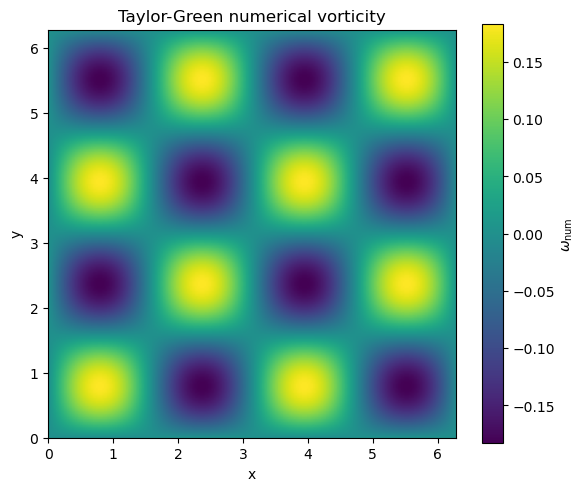

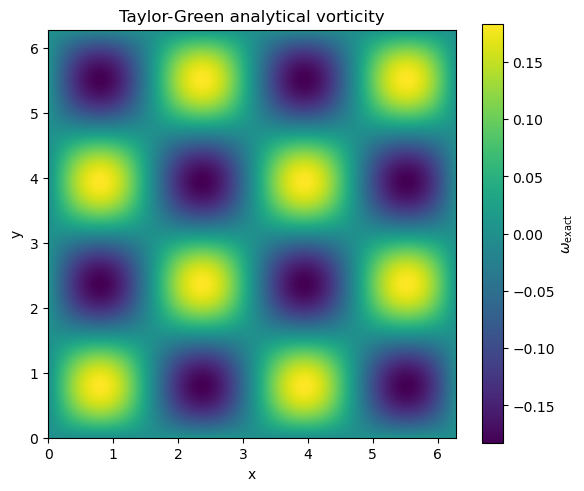

In [15]:
vmin = min(np.min(omega_num), np.min(omega_exact_final))
vmax = max(np.max(omega_num), np.max(omega_exact_final))

plt.figure(figsize=(6, 5))
plt.imshow(
    omega_num,
    origin="lower",
    extent=[0, L_x, 0, L_y],
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(label=r"$\omega_{\mathrm{num}}$")
plt.title("Taylor-Green numerical vorticity")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(
    omega_exact_final,
    origin="lower",
    extent=[0, L_x, 0, L_y],
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(label=r"$\omega_{\mathrm{exact}}$")
plt.title("Taylor-Green analytical vorticity")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

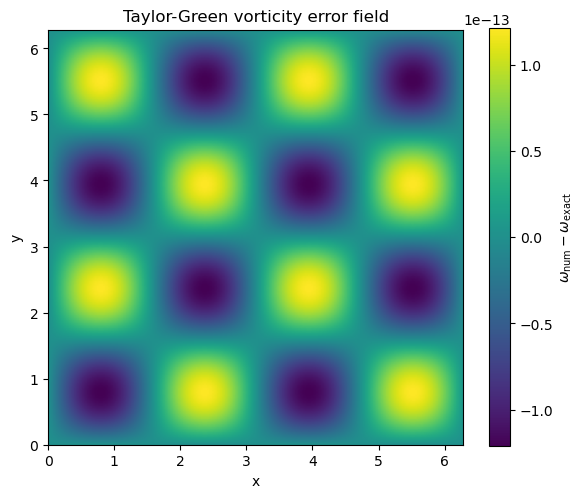

In [16]:
plt.figure(figsize=(6, 5))
plt.imshow(
    error_final,
    origin="lower",
    extent=[0, L_x, 0, L_y]
)
plt.colorbar(label=r"$\omega_{\mathrm{num}}-\omega_{\mathrm{exact}}$")
plt.title("Taylor-Green vorticity error field")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

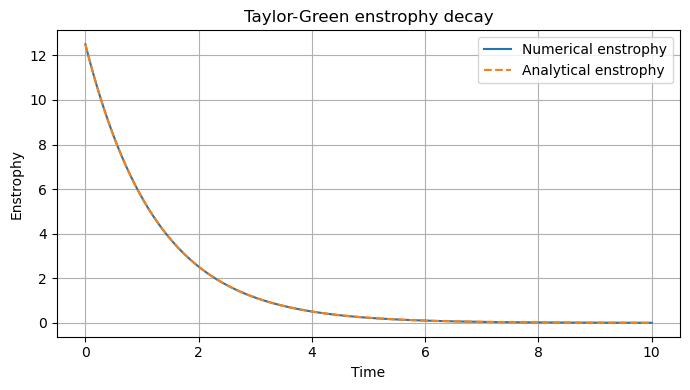

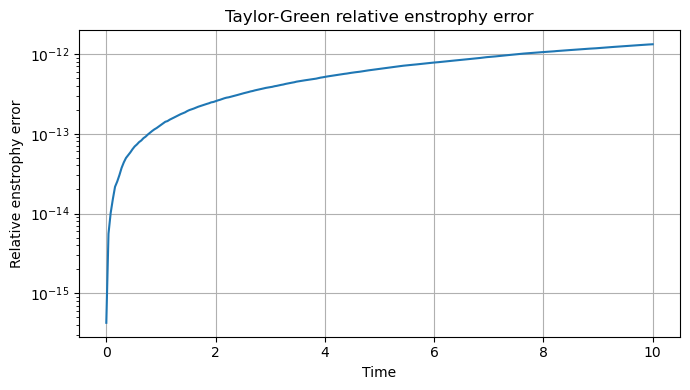

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(time_history, enstrophy_history, label="Numerical enstrophy")
plt.plot(time_history, exact_enstrophy_history, "--", label="Analytical enstrophy")
plt.xlabel("Time")
plt.ylabel("Enstrophy")
plt.title("Taylor-Green enstrophy decay")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.semilogy(time_history, relative_enstrophy_error_history)
plt.xlabel("Time")
plt.ylabel("Relative enstrophy error")
plt.title("Taylor-Green relative enstrophy error")
plt.grid(True)
plt.tight_layout()
plt.show()

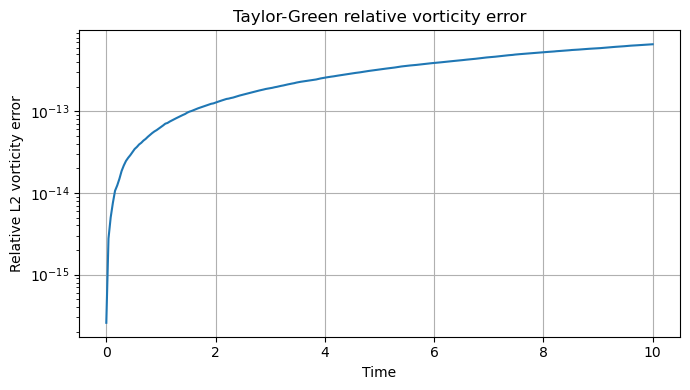

In [18]:
plt.figure(figsize=(7, 4))
plt.semilogy(time_history, relative_L2_error_history)
plt.xlabel("Time")
plt.ylabel("Relative L2 vorticity error")
plt.title("Taylor-Green relative vorticity error")
plt.grid(True)
plt.tight_layout()
plt.show()